valid lines [0]
[[np.int64(0)]]
[[np.int32(1), np.int32(2)]]


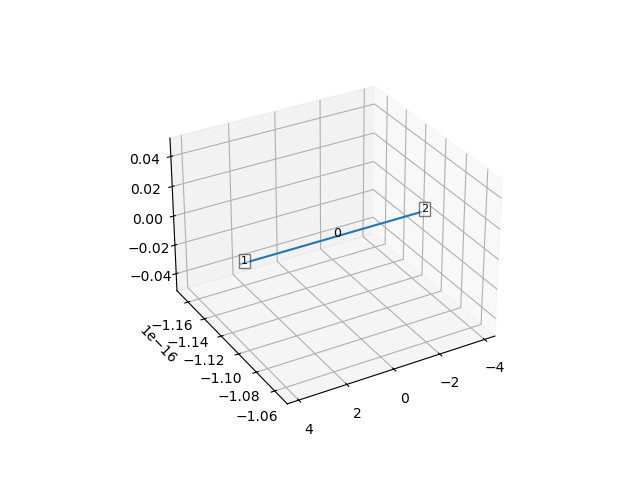

valid lines [0]
[[np.int64(0)]]
[[np.int32(1), np.int32(2)]]


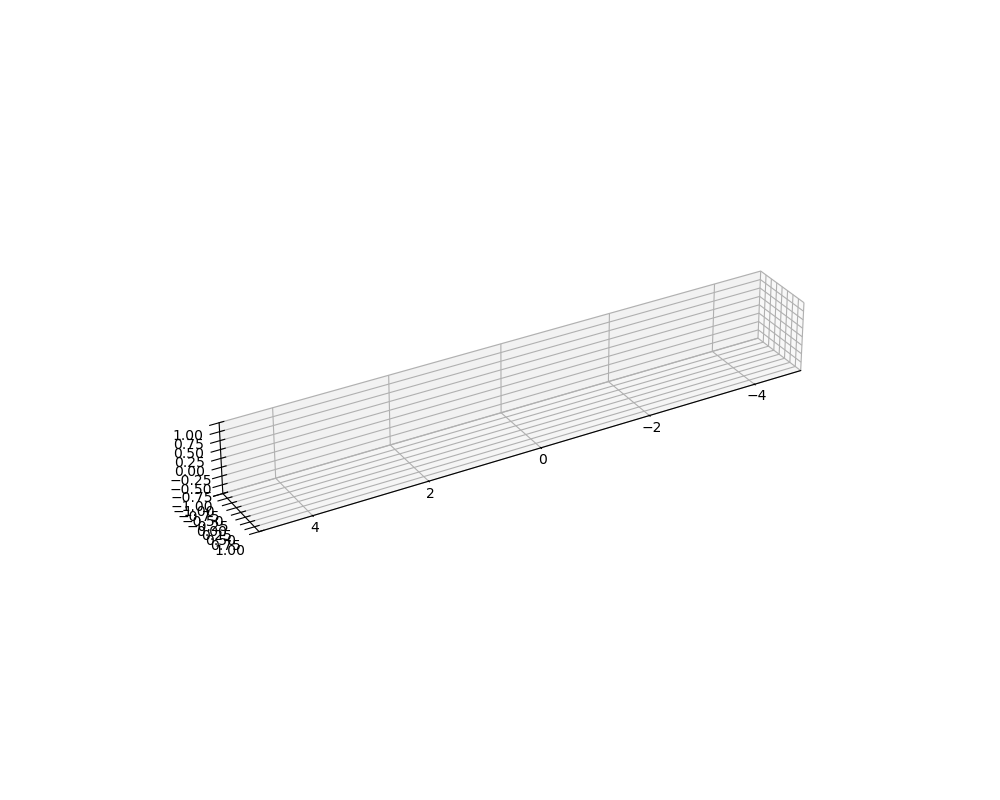

In [ ]:
%matplotlib widget
from fracprint import processor_retract as processor
from fracprint import writer_retract as writer


# File settings
filedir = './Rhino/'       # Directory of the file you're loading
filename = 'line.txt'   # Name of the file you're loading
fileout = 'retract_line_E40_F40.gcode'          # Name of the output file

# Print settings
d = 0.8                    # Target fibril diameter in mm
x_offset, y_offset = 0, 0  # Offset of the print from the origin
bed_temperature = 0        # Bed temperature in degrees C
floor = -26.5              # z-coord at which nozzle hits printbed in mm
z_min = -25                # Minimum z-coord for the print in mm
roof = 0                   # Height to retract printhead to at end of print
f_print = 200              # Printhead speed in mm / min
E_clean = 10               # Amount to extrude in cleaning line

# Retraction / stringing control
retract_on_lift = True      # Retract while lifting out of bath at path ends
E_retract = 30             # Retraction amount (E-units)
F_retract = 50            # Retraction feedrate
lift_clearance = 5          # Extra Z clearance above max printed Z
unretract_before_print = False  # Prime back before starting each new path

# Write to file
settings = processor.build_settings(filedir, filename, fileout, d, x_offset, y_offset, bed_temperature, floor, z_min, roof, f_print, E_clean, retract_on_lift, E_retract, F_retract, lift_clearance, unretract_before_print)
df, line_order_grouped = processor.shape_prep(settings)
df_print = writer.gcode_writer(df, settings, line_order_grouped)

# animation
data_frame, terminal_points, nodes = processor.node_finder(df)
eline_order, enode_order, eline_order_grouped, enode_order_grouped= processor.eulerficator(data_frame, terminal_points, nodes)

ani = processor.node_plotter(data_frame, terminal_points, eline_order, enode_order, enode_order_grouped)